In [24]:
import pyradtran
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

solar_config_path = Path('config/arctic_cloud_experiment_solar_spectral.yaml')
thermal_config_path = Path('config/arctic_cloud_experiment_thermal.yaml')

In [26]:
# Arctic stratus parameter space (libRadtran units)
cbh   = [0.3]        # km
cth   = [1.0]        # km

lwps = np.arange(0, 150, 10)
lwcs = lwps / 700  # convert to kg m^-3 to fill the 700 m layer uniformly
reffs = [15]           

cbh = [0.3] * len(lwcs)
cth = [1] * len(lwcs)

times = pd.date_range("2024-03-01 12:00", periods=2, freq="7d")
lats = np.arange(80, 60, -10) # this is a trick to sample through a high number of SZA... vary lat and time together...
print(lats)
lon = [0] * len(times)
altitudes = [0, 1, 10, 100]
surface_temperatures = [255] * len(times)


ds = xr.Dataset(
    coords={
        "time": times, 
        "latitude": (("time",), lats), 
        "longitude": (("time",), lon),
        "altitude": (("altitude",), altitudes)
    },
    data_vars={
        "lwc": (("lwc",), lwcs),
        "reff": (("reff",), reffs),
        "cth": (("lwc",), cth),
        "cbh": (("lwc",), cbh),
        "surface_temperature": (("time",), surface_temperatures),
        #"albedo_sw": (("albedo",), albedos_sw),
        #"albedo_lw": (("albedo",), albedos_lw),
    }
)

ds_ = ds.drop_vars(["lwc", "reff", "cth", "cbh"])

ds_sim_no_cloud_solar = ds_.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar_spectral.yaml',
    surface_temperature_var='surface_temperature',
    #albedo_var='albedo_sw',
    save_to_file=True, 
    return_dataset=True,
    show_progress=True,
    parameter_overrides={
        'albedo_library IGBP' : '',
        'brdf_rpv_type' : '19'
    }
)

ds_sim_cloudy_solar = ds.pyradtran.run(
    config_path='config/arctic_cloud_experiment_solar_spectral.yaml',
    cloud_wc_var='lwc',
    cloud_reff_var='reff',
    cloud_top_var='cth',
    cloud_bottom_var='cbh',
    surface_temperature_var='surface_temperature',
    save_to_file=True, 
    return_dataset=True,
    show_progress=True,
    parameter_overrides={
        'albedo_library IGBP' : '',
        'brdf_rpv_type' : '19'
    }
)


[80 70]


Running simulations:   0%|          | 0/2 [00:00<?, ?sim/s]

Running simulations: 100%|██████████| 30/30 [14:16<00:00, 28.56s/sim, Success=30, Total=30] 


In [27]:
ds_sim_no_cloud_solar['albedo_sw'] = ds_sim_no_cloud_solar['eup'] / ds_sim_no_cloud_solar['eglo']
ds_sim_cloudy_solar['albedo_sw'] = ds_sim_cloudy_solar['eup'] / ds_sim_cloudy_solar['eglo']

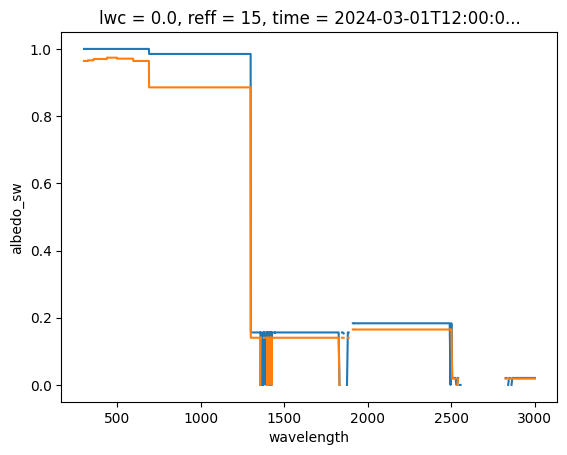

In [29]:
ds_sim_no_cloud_solar['albedo_sw'].isel(altitude=0, time=0).squeeze().plot()
ds_sim_cloudy_solar['albedo_sw'].isel(altitude=0, lwc=0, time=0).squeeze().plot()